# Benchmark Models (LogHAR)

In [2]:
import pandas as pd 
import numpy as np
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
df = pd.read_csv(file_path)

# Convert "Date" column to datetime 
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date").set_index("Date")

df.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_overnight,RV_total,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000001,0.000109,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000029,0.000158,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000049,0.000117,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000008,0.000117,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000007,0.000097,3.748493e-08,0.001214,-9.243673,-9.322462


## 1.2 logHAR Model

Why use logs for RV?
Realized variance $RV_t$ is: 
* strictly non-negative
* extremely right-skewed (big spikes in crises)
* heteroskedastic (errors are larger when volatility is high)

Taking logs: 
$$
y_t = \log(RV_t)
$$

often gives: 
* a distribution closer to normal
* more stable variance (less extreme spikes)
* better-behaved OLS residuals
* forecasts that are (after exponentiation) strictly positive

So logHAR often improves robustness, especially around crises  log

The logHAR model: 
$$
\log(RV_t)
= \beta_0
+ \beta_1 \log(RV_{t-1})
+ \beta_2 \log(RV_{t-1\mid t-5})
+ \beta_3 \log(RV_{t-1\mid t-22})
+ u_t
$$

In [6]:
# 0) Dedicated dataframe for logHAR
df_logHAR = df.sort_index().copy()

# 1) Use log RV
lr = df_logHAR["log_RV_total"]

# 2) logHAR regressors available at time t
df_logHAR["logRV_d"] = lr
df_logHAR["logRV_w"] = lr.rolling(window=5).mean()
df_logHAR["logRV_m"] = lr.rolling(window=22).mean()

# 3) Target: next day's log RV
df_logHAR["logRV_target"] = lr.shift(-1)

In [8]:
df_logHAR = df_logHAR.dropna(subset=["logRV_d", "logRV_w", "logRV_m", "logRV_target"])

print("First usable date:", df_logHAR.index.min())
print("Last usable date:", df_logHAR.index.max())
print("Number of usable observations:", len(df_logHAR))

First usable date: 1998-03-31 00:00:00+02:00
Last usable date: 2020-08-06 00:00:00+02:00
Number of usable observations: 5689


**Deciding on train, validation, and test splits:**
* Train = 1998 - 2012 (Train includes dot-com + GFC → rich volatility regimes) *~60–65% train*
* Validation = 2013 - 2015 (Validation includes Euro crisis aftershocks) *~15% validation*
* Test = 2016 - 2020 (Test includes calm + COVID shock) *~20–25% test*

In [11]:
# Define split dates (same as HAR)
train_end = "2012-12-31"
val_end   = "2015-12-31"

# Chronological split
df_train = df_logHAR.loc[:train_end]
df_val   = df_logHAR.loc[train_end:val_end]
df_test  = df_logHAR.loc[val_end:]

# Remove boundary overlap (same logic as before)
df_val   = df_val.iloc[1:]
df_test  = df_test.iloc[1:]

# Print diagnostics
print("Train observations:", len(df_train))
print("Validation observations:", len(df_val))
print("Test observations:", len(df_test))

print("\nTrain period:", df_train.index.min(), "to", df_train.index.max())
print("Validation period:", df_val.index.min(), "to", df_val.index.max())
print("Test period:", df_test.index.min(), "to", df_test.index.max())

Train observations: 3745
Validation observations: 768
Test observations: 1176

Train period: 1998-03-31 00:00:00+02:00 to 2012-12-31 00:00:00+01:00
Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00


#### LogHAR on Training set

In [14]:
import statsmodels.api as sm

# Regressors and target (training only)
X_train = df_train[["logRV_d", "logRV_w", "logRV_m"]]
y_train = df_train["logRV_target"]

# Add intercept
X_train = sm.add_constant(X_train)

# Estimate OLS
loghar_model = sm.OLS(y_train, X_train).fit()

print(loghar_model.summary())

                            OLS Regression Results                            
Dep. Variable:           logRV_target   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     3238.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:04:22   Log-Likelihood:                -2790.0
No. Observations:                3745   AIC:                             5588.
Df Residuals:                    3741   BIC:                             5613.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4269      0.094     -4.536      0.0

**Estimated model:** 
$$
\log(RV_{t+1})
= -0.427
+ 0.270 \, \log(RV_t)
+ 0.514 \, \log\!\left(RV_t^{(5)}\right)
+ 0.170 \, \log\!\left(RV_t^{(22)}\right)
+ \varepsilon_{t+1}
$$

R-squared of **72%**, up from **58%** with the standard HAR model because the log-transform reduces skewness, stabilizes variance, and makes linear regression more appropriate. Skew is **0.08** which is much closer to symmetric compared to the standard HAR model. 

SUm of coefficients is close to 1 **(0.954)** which suggests that log-volatility behaves like a near unit-root persistent process. 

**Interpret output as elasticities:** 
* A 1% increase in yesterday's $RV$
* Translates into approximately 0.27% increase in tomorrow's $RV$
* Weekly component dominates **(0.51)** (Medium-term volatility persistence is strongest)


#### logHAR on Rolling Estimation (Validation + Test)

Note that we implement a log-bias correction since we evaluate MSE in $RV$ terms. This implies that when we convert the forecasted $log(RV)$ back to RV, we perform the following equation: 
$$
\widehat{RV}_{t+1}
= \exp\!\left(
\widehat{\log(RV_{t+1})}
+ \tfrac{1}{2}\hat{\sigma}^2
\right)
$$

In [18]:
from tqdm import tqdm

# Evaluation window = validation + test
df_eval = pd.concat([df_val, df_test])

predictions_rv = []
actuals_rv = []
dates = []

for current_date in tqdm(df_eval.index):

    # Expanding window: all rows strictly before current_date
    df_expanding = df_logHAR.loc[:current_date].iloc[:-1]

    # Fit in LOG space
    X = df_expanding[["logRV_d", "logRV_w", "logRV_m"]]
    y = df_expanding["logRV_target"]

    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()

    # Forecast row (1-row DataFrame) in LOG space
    X_fore = df_logHAR.loc[[current_date], ["logRV_d", "logRV_w", "logRV_m"]]
    X_fore = sm.add_constant(X_fore, has_constant="add")
    X_fore = X_fore.reindex(columns=X.columns)

    # 1) Forecast in log space
    log_forecast = float(model.predict(X_fore).iloc[0])

    # 2) Bias correction term (residual variance from the fitted log regression)
    sigma2 = float(model.mse_resid)

    # 3) Convert back to RV units WITH log-bias correction
    rv_forecast_bc = float(np.exp(log_forecast + 0.5 * sigma2))

    # Actual RV_{t+1} in RV units (aligned with logRV_target)
    rv_actual = float(np.exp(df_logHAR.loc[current_date, "logRV_target"]))

    predictions_rv.append(rv_forecast_bc)
    actuals_rv.append(rv_actual)
    dates.append(current_date)

df_forecast_logHAR_bc = pd.DataFrame({"Forecast": predictions_rv, "Actual": actuals_rv}, index=dates)

print(df_forecast_logHAR_bc.head())
print("\nForecast df shape:", df_forecast_logHAR_bc.shape)

100%|██████████████████████████████████████| 1944/1944 [00:05<00:00, 347.62it/s]

                           Forecast    Actual
2013-01-02 00:00:00+01:00  0.000050  0.000027
2013-01-03 00:00:00+01:00  0.000036  0.000032
2013-01-04 00:00:00+01:00  0.000040  0.000028
2013-01-07 00:00:00+01:00  0.000038  0.000027
2013-01-08 00:00:00+01:00  0.000043  0.000030

Forecast df shape: (1944, 2)


In [19]:
# Define validation and test ranges
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

# Split the BIAS-CORRECTED forecast dataframe
df_forecast_val = df_forecast_logHAR_bc.loc[val_start:val_end]
df_forecast_test = df_forecast_logHAR_bc.loc[test_start:test_end]

# Compute MSE
mse_val = np.mean((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
mse_test = np.mean((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)

# Print in identical structure
print(f"Validation period: {val_start} to {val_end} | n = {len(df_forecast_val)}")
print(f"Test period: {test_start} to {test_end} | n = {len(df_forecast_test)}")

print("\nValidation MSE:", mse_val)
print("Test MSE:", mse_test)

Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00 | n = 768
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00 | n = 1176

Validation MSE: 1.145134980150071e-08
Test MSE: 2.5347594156584098e-08


Test MSE is double the size of Validation MSE, which is economically inuitive as the test period includes the 2018 volatility spike and the 2020 COVID shock. Volatility forecasting models struggle more during crisis regimes.

Hom much better HAR is than simply forecasting historical mean: 
$$
R^2_{\text{OOS}}
= 1
- \frac{\sum \left( RV_{t+1} - \widehat{RV}_{t+1} \right)^2}
       {\sum \left( RV_{t+1} - \overline{RV} \right)^2}
$$

#### Plotting performance during entire Test period

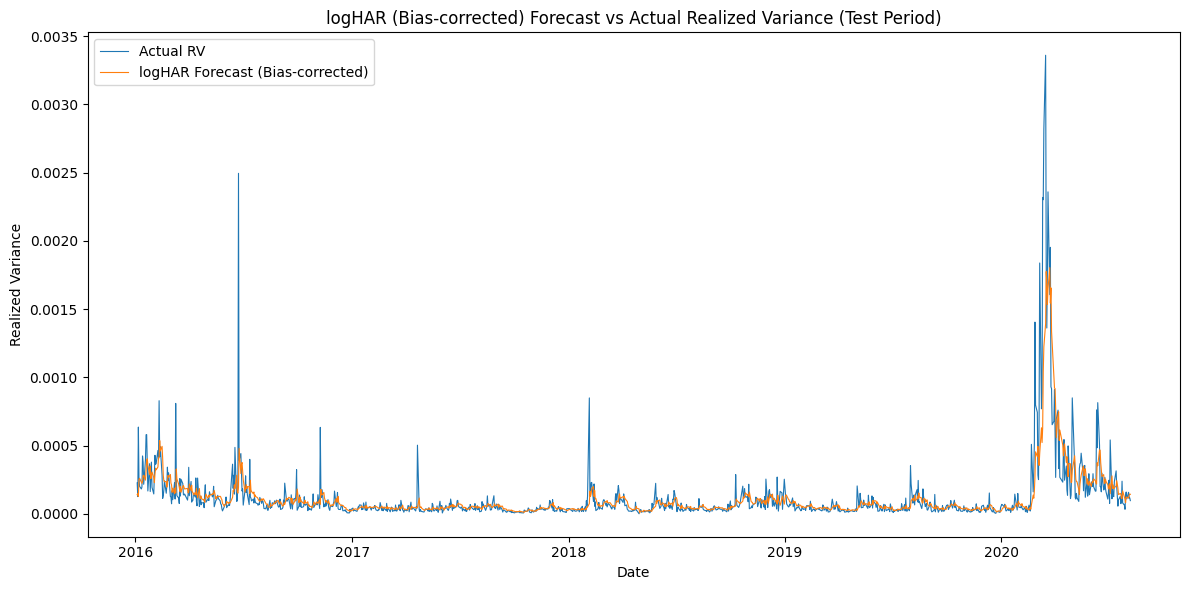

In [23]:
import matplotlib.pyplot as plt

# Use test-period forecasts from bias-corrected logHAR
df_plot = df_forecast_logHAR_bc.loc[df_test.index.min():df_test.index.max()].copy()

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot["Actual"], 
         label="Actual RV", 
         linewidth=0.8)

plt.plot(df_plot.index, df_plot["Forecast"], 
         label="logHAR Forecast (Bias-corrected)", 
         linewidth=0.8)

plt.title("logHAR (Bias-corrected) Forecast vs Actual Realized Variance (Test Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()

#### Compare with using historical average

In [25]:
# Benchmark: mean RV from TRAINING sample only (LEVELS)
mean_train = df_train["logRV_target"]  # careful: this is log
mean_train = np.exp(mean_train).mean()  # convert to RV level mean

# Split bias-corrected forecast dataframe
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

df_forecast_val = df_forecast_logHAR_bc.loc[val_start:val_end]
df_forecast_test = df_forecast_logHAR_bc.loc[test_start:test_end]

# --- Validation ---
sse_val = np.sum((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
sse_val_bench = np.sum((df_forecast_val["Actual"] - mean_train)**2)

r2_oos_val = 1 - (sse_val / sse_val_bench)

# --- Test ---
sse_test = np.sum((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)
sse_test_bench = np.sum((df_forecast_test["Actual"] - mean_train)**2)

r2_oos_test = 1 - (sse_test / sse_test_bench)

print("Out-of-sample R^2 (Validation, logHAR BC):", r2_oos_val)
print("Out-of-sample R^2 (Test, logHAR BC):", r2_oos_test)

Out-of-sample R^2 (Validation, logHAR BC): 0.4028647662112691
Out-of-sample R^2 (Test, logHAR BC): 0.6209071501977064


* $R^2_{\text{OOS}} > 0$ --> model beats mean forecast
* $R^2_{\text{OOS}} = 0$ --> same as mean forecast
* $R^2_{\text{OOS}} < 0$ --> wore than mean forecast

**Comment:** logHAR outperforms slightly outperforms level HAR during the validation period (2013 - 2015), which suggests that log transformation improves stability in moderate volatility regimes and weekly persistence is captured slightly better in log space. 

However, level HAR wins over logHAR during the test period (2016 - 2020). This implies that during extreme volatility spijes, modeling in levels better captuures magnitude dynamics. Log models compress large movements, even after bias correction. 

## Performance during COVID

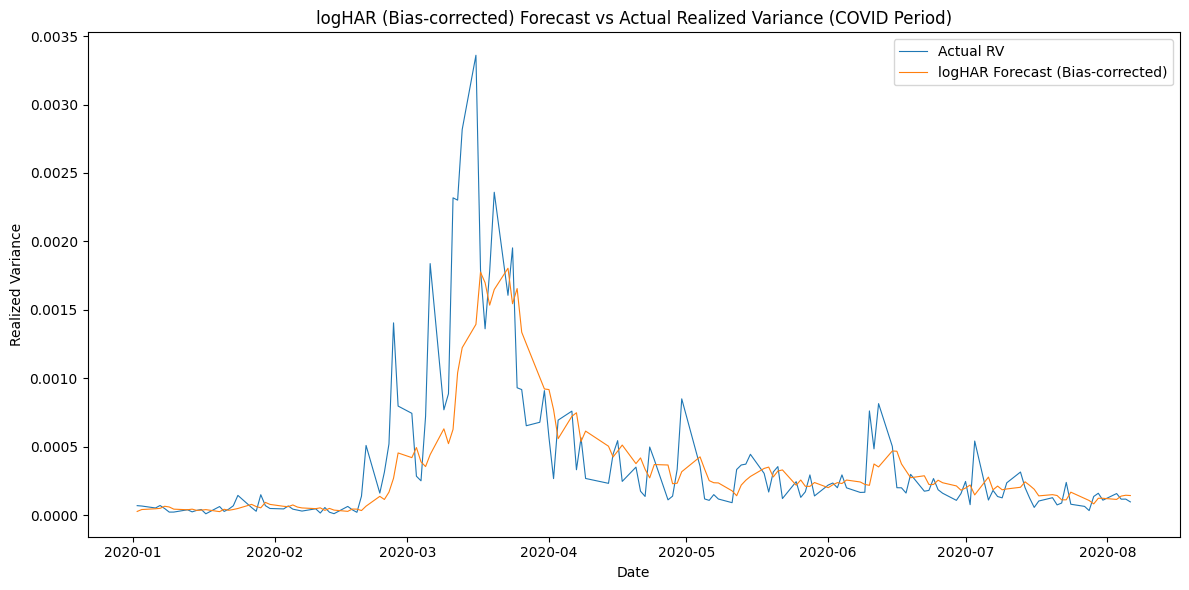

In [29]:
# Select COVID period from bias-corrected logHAR forecasts
df_covid = df_forecast_logHAR_bc.loc["2020-01-01":].copy()

plt.figure(figsize=(12,6))

plt.plot(df_covid.index, df_covid["Actual"], 
         label="Actual RV", 
         linewidth=0.8)

plt.plot(df_covid.index, df_covid["Forecast"], 
         label="logHAR Forecast (Bias-corrected)", 
         linewidth=0.8)

plt.title("logHAR (Bias-corrected) Forecast vs Actual Realized Variance (COVID Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()